In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [55]:
credit_risk = pd.read_csv("credit_risk.csv")

In [56]:
list(credit_risk.columns)

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default.payment.next.month']

In [57]:
credit_risk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [58]:
credit_risk['default.payment.next.month'].value_counts()

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

In [59]:
target = credit_risk['default.payment.next.month']

In [60]:
y = target

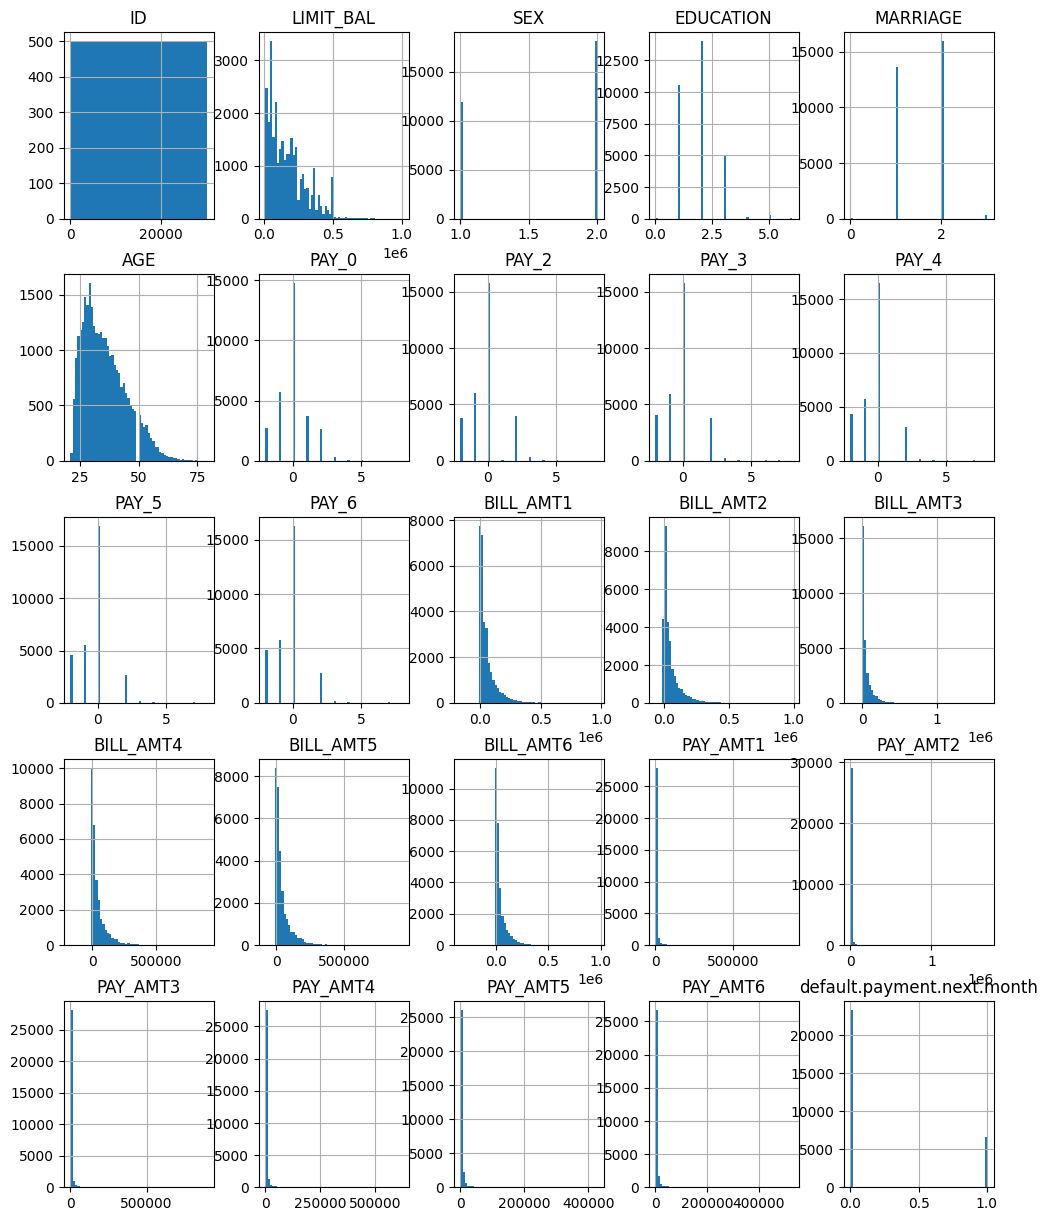

In [61]:
credit_risk.hist(bins=60, figsize=(12,15))
plt.show()

### Feature Dictionary

- LIMIT_BAL: Credit limit assigned to the customer
- PAY_0 – PAY_6: Repayment status history (delay severity)
- BILL_AMT1 – BILL_AMT6: Monthly bill statements
- PAY_AMT1 – PAY_AMT6: Actual payments made


In [62]:
credit_risk.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [63]:
credit_risk.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [64]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    credit_risk, test_size=0.2, random_state=42,
    stratify = credit_risk['default.payment.next.month']
)

In [65]:
X_train = train_set.drop("default.payment.next.month", axis=1)
y_train = train_set["default.payment.next.month"]

In [66]:
X_train.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,...,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,2.400000e+04,24000.000000,24000.000000,24000.000000,24000.000000
mean,14973.683417,167364.666667,1.604750,1.853792,1.552875,35.432625,-0.014125,-0.134083,-0.166917,-0.221333,...,46861.880083,43156.661458,40164.412625,38675.979875,5623.556292,5.879975e+03,5215.777583,4790.331833,4769.941750,5229.905500
std,8641.664947,129511.313151,0.488915,0.792375,0.521903,9.195256,1.123155,1.198818,1.194166,1.161924,...,68403.933692,64046.730878,60627.850612,59308.737828,16148.316646,2.025298e+04,17513.554475,15060.693585,15048.470405,17850.346975
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-61506.000000,-81334.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,7513.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2652.000000,2332.000000,1746.000000,1225.000000,1000.000000,8.400000e+02,390.000000,291.000000,246.000000,100.000000
50%,14966.000000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,20031.000000,19004.500000,18102.500000,16993.000000,2100.500000,2.014000e+03,1805.500000,1500.000000,1500.000000,1500.000000
75%,22438.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,60033.750000,54386.500000,50142.250000,48977.250000,5018.250000,5.000000e+03,4580.500000,4015.250000,4040.000000,4000.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,75.000000,8.000000,8.000000,8.000000,8.000000,...,855086.000000,891586.000000,927171.000000,961664.000000,873552.000000,1.215471e+06,896040.000000,621000.000000,426529.000000,528666.000000


In [67]:
X_test = test_set.drop("default.payment.next.month", axis=1)
y_test = test_set["default.payment.next.month"]

In [68]:
y_train.describe()

count    24000.000000
mean         0.221208
std          0.415069
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: default.payment.next.month, dtype: float64

In [69]:
credit_risk.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

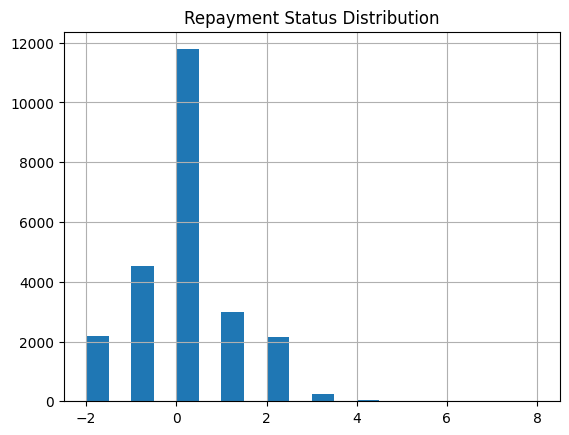

In [70]:
train_set['PAY_0'].hist(bins=20)
plt.title("Repayment Status Distribution")
plt.show()

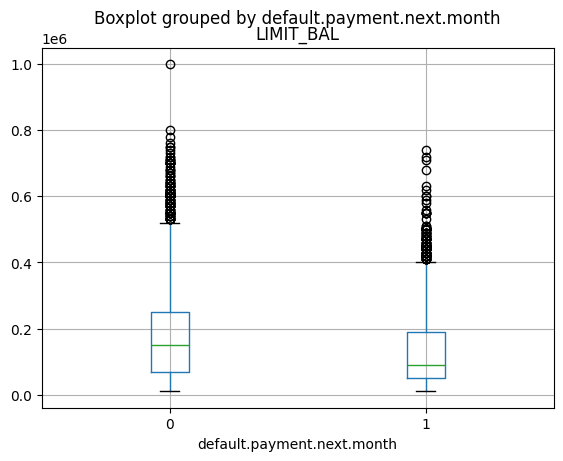

In [71]:
train_set.boxplot(column='LIMIT_BAL', by='default.payment.next.month')
plt.show()

In [72]:
credit_risk['SEX'].value_counts()

SEX
2    18112
1    11888
Name: count, dtype: int64

In [73]:
credit_risk['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [74]:
credit_risk['MARRIAGE'].value_counts().sort_index()

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

In [75]:
df = train_set.copy()

correlations

In [76]:
corr_matrix = df.corr(numeric_only=True)

In [77]:
corr_matrix["default.payment.next.month"].sort_values(ascending = False)

default.payment.next.month    1.000000
PAY_0                         0.327671
PAY_2                         0.265527
PAY_3                         0.238930
PAY_4                         0.220063
PAY_5                         0.203260
PAY_6                         0.188717
EDUCATION                     0.026127
AGE                           0.012830
BILL_AMT6                    -0.008177
BILL_AMT5                    -0.009710
ID                           -0.010718
BILL_AMT4                    -0.013726
BILL_AMT2                    -0.018048
BILL_AMT3                    -0.018280
MARRIAGE                     -0.019661
BILL_AMT1                    -0.022720
SEX                          -0.043862
PAY_AMT5                     -0.052609
PAY_AMT6                     -0.053280
PAY_AMT3                     -0.053863
PAY_AMT4                     -0.055313
PAY_AMT2                     -0.065078
PAY_AMT1                     -0.073441
LIMIT_BAL                    -0.160995
Name: default.payment.nex

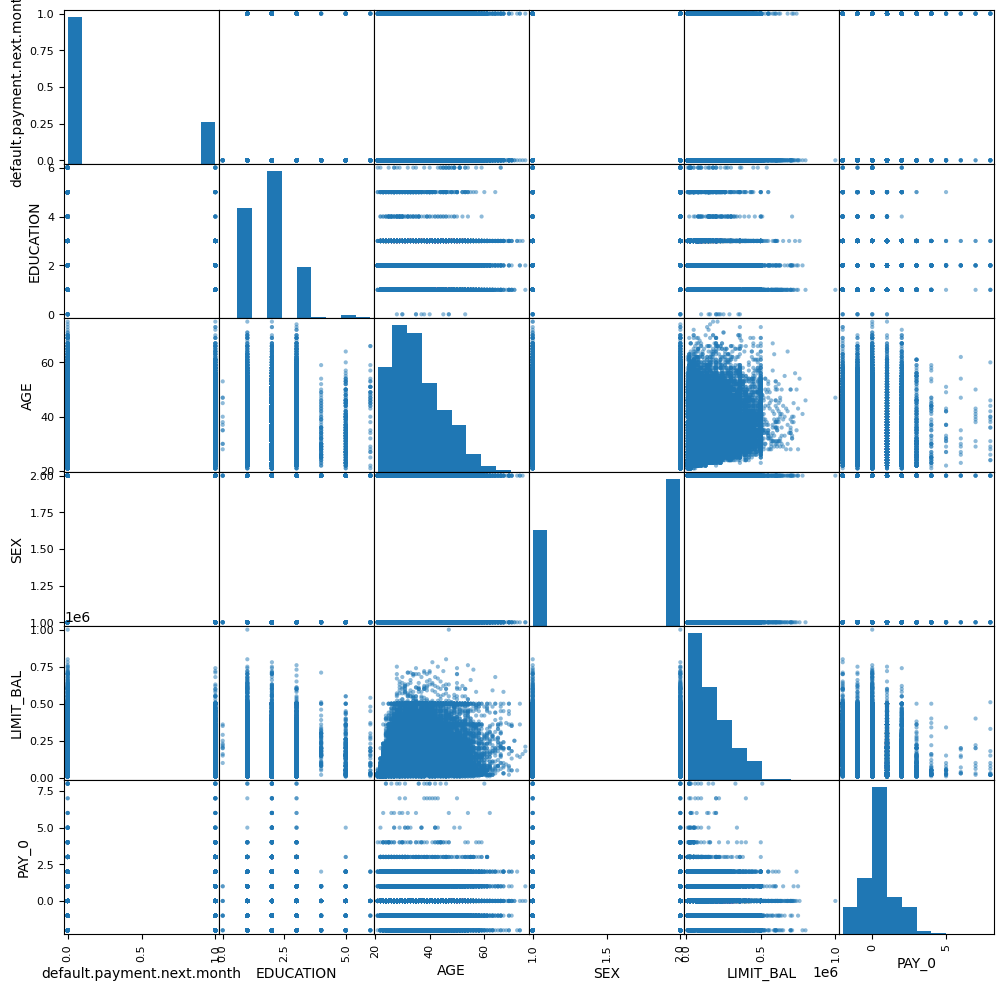

In [78]:
from pandas.plotting import scatter_matrix

attributes = ["default.payment.next.month", "EDUCATION", "AGE", "SEX", "LIMIT_BAL", "PAY_0"]
scatter_matrix(df[attributes], figsize=(12,12))
plt.show()

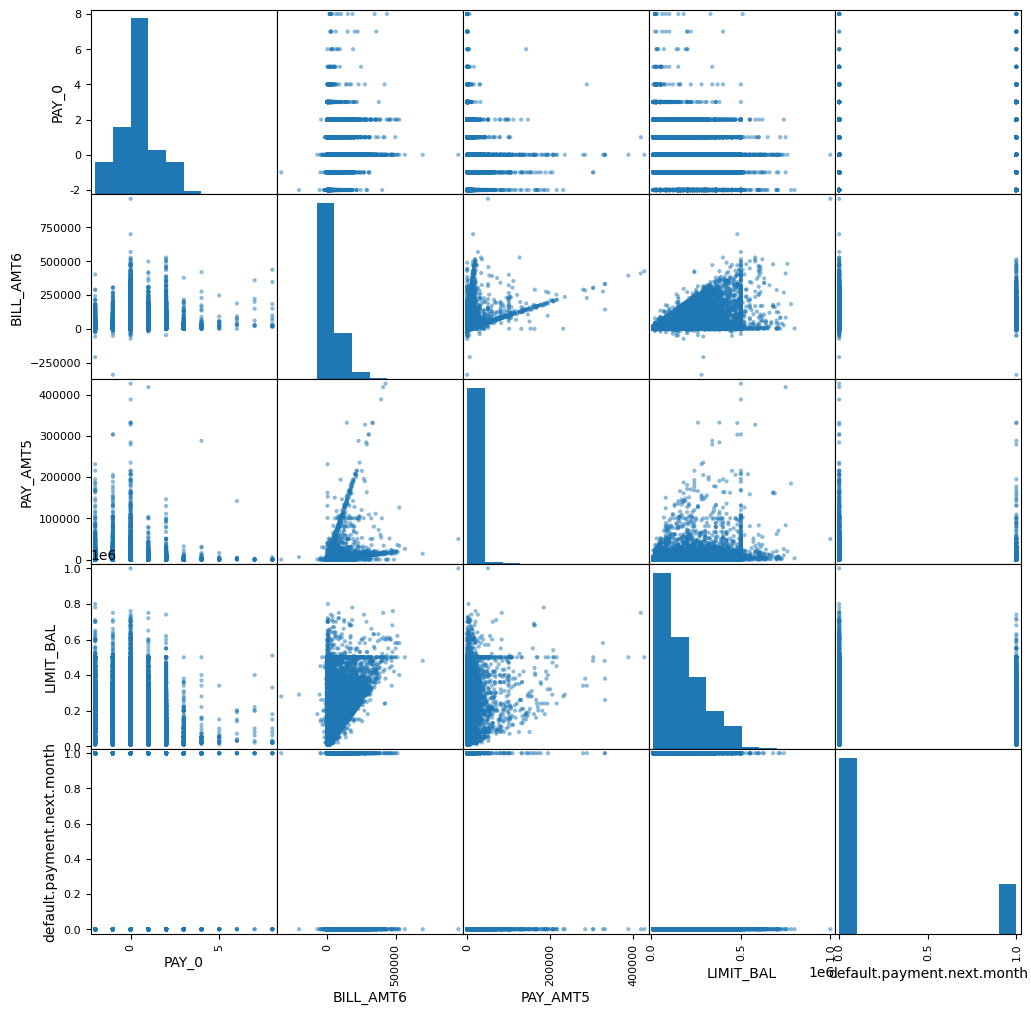

In [79]:
attributes = ["PAY_0", "BILL_AMT6", "PAY_AMT5", "LIMIT_BAL", "default.payment.next.month"]
scatter_matrix(df[attributes], figsize=(12,12))
plt.show()

PREPARING DATA FOR ML

Handling Text and categorical Attributes

In [80]:
X_train = X_train.drop(columns=['ID'])
X_test = X_test.drop(columns=['ID'])
df = df.drop(columns=['ID'])

In [81]:
credit_risk = credit_risk.drop(columns=['ID'])

Feature Grouping

In [82]:
numerical_features = [
    'LIMIT_BAL',
    'AGE',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

In [83]:
nominal_categorical_features = [
    'SEX',
    'EDUCATION',
    'MARRIAGE'
]

In [84]:
ordinal_features = [
    'PAY_0', 'PAY_2', 'PAY_3',
    'PAY_4', 'PAY_5', 'PAY_6'
]

In [85]:
target = 'default.payment.next.month'


In [86]:
df.groupby('EDUCATION')[target].mean()

EDUCATION
0    0.000000
1    0.192904
2    0.237562
3    0.250064
4    0.061856
5    0.063830
6    0.166667
Name: default.payment.next.month, dtype: float64

In [87]:
df.groupby('MARRIAGE')[target].mean()

MARRIAGE
0    0.106383
1    0.233015
2    0.210370
3    0.282353
Name: default.payment.next.month, dtype: float64

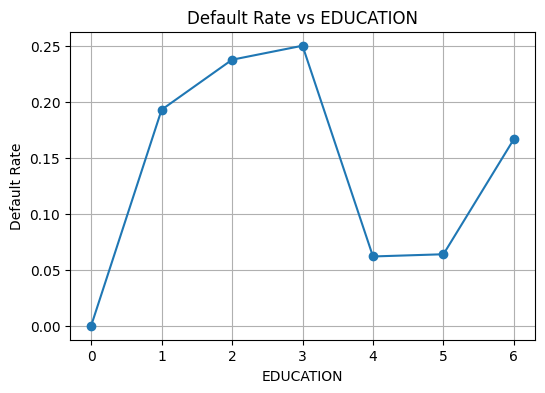

In [88]:
default_rate = (
    df.groupby("EDUCATION")[target]
      .mean()
      .reset_index()
      .sort_values("EDUCATION")
)

plt.figure(figsize=(6,4))
plt.plot(default_rate["EDUCATION"], default_rate[target], marker='o')
plt.xlabel("EDUCATION")
plt.ylabel("Default Rate")
plt.title(f"Default Rate vs {"EDUCATION"}")
plt.grid(True)
plt.show()

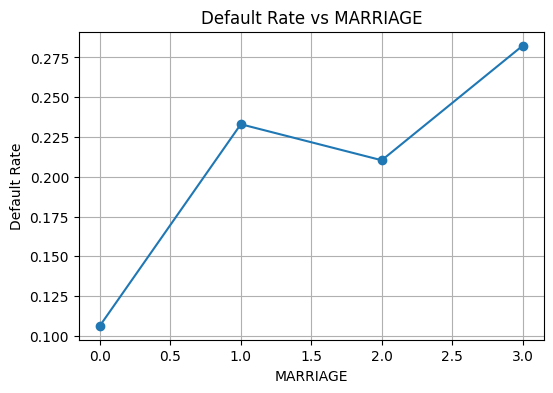

In [89]:
default_rate = (
    df.groupby("MARRIAGE")[target]
      .mean()
      .reset_index()
      .sort_values("MARRIAGE")
)

plt.figure(figsize=(6,4))
plt.plot(default_rate["MARRIAGE"], default_rate[target], marker='o')
plt.xlabel("MARRIAGE")
plt.ylabel("Default Rate")
plt.title(f"Default Rate vs {"MARRIAGE"}")
plt.grid(True)
plt.show()

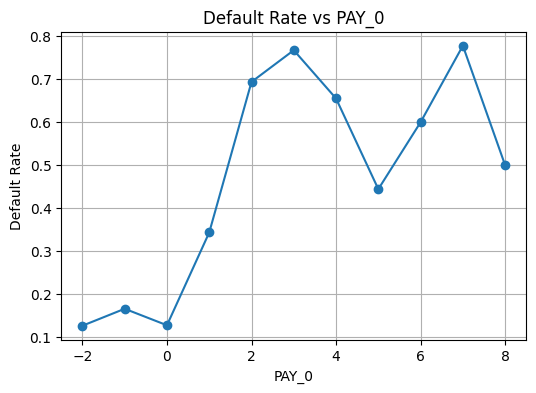

In [90]:
default_rate = (
    df.groupby("PAY_0")[target]
      .mean()
      .reset_index()
      .sort_values("PAY_0")
)

plt.figure(figsize=(6,4))
plt.plot(default_rate["PAY_0"], default_rate[target], marker='o')
plt.xlabel("PAY_0")
plt.ylabel("Default Rate")
plt.title(f"Default Rate vs {"PAY_0"}")
plt.grid(True)
plt.show()

In [91]:
df.groupby('PAY_0')[target].mean()

PAY_0
-2    0.126934
-1    0.166335
 0    0.128003
 1    0.343667
 2    0.693639
 3    0.767347
 4    0.655172
 5    0.444444
 6    0.600000
 7    0.777778
 8    0.500000
Name: default.payment.next.month, dtype: float64

In [92]:
credit_risk['PAY_0'].value_counts()

PAY_0
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9
Name: count, dtype: int64

### Categorical Data Cleaning

Invalid and rare categorical levels were identified using frequency and stability analysis.
Such categories were merged into an "Other/Unknown" group to reduce noise prior to encoding.
Ordinal delinquency variables were capped to reduce the influence of extreme rare values.

In [93]:
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)

In [94]:
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

In [95]:
freq = df['EDUCATION'].value_counts(normalize=True)
freq

EDUCATION
2    0.469000
1    0.352292
3    0.162625
4    0.016083
Name: proportion, dtype: float64

In [96]:
rare_cats = freq[freq < 0.005].index
df['EDUCATION'] = df['EDUCATION'].replace(rare_cats, 4)

In [97]:
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

for col in pay_cols:
    df[col] = df[col].clip(lower=-1, upper=4)

Garbage Management Tranformer

In [98]:
from sklearn.base import BaseEstimator, TransformerMixin

class CreditGarbageClearner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()

        # education garbage
        X['EDUCATION'] = X['EDUCATION'].replace([0, 5, 6], 4)

        # marraige garbage
        X['MARRIAGE'] = X['MARRIAGE'].replace(0, 3)

        # pay columns clipping
        pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
        for col in pay_cols:
            X[col] = X[col].clip(lower=-1, upper=4)

        return X

In [99]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

ord_pipeline = Pipeline([
    ('encoder', OrdinalEncoder())
])

preprocessing = ColumnTransformer([
    ('num', num_pipeline, numerical_features),
    ('cat', cat_pipeline, nominal_categorical_features),
    ('ord', ord_pipeline, ordinal_features)
])

In [100]:
from sklearn.linear_model import LogisticRegression

full_pipeline = Pipeline([
    ('grabage_cleaning', CreditGarbageClearner()),
    ('preprocessing', preprocessing),
    ('model', LogisticRegression(max_iter=1000))
])

training and evaaluating 

In [101]:
full_pipeline.fit(X_train, y_train)

y_pred = full_pipeline.predict(X_test)
y_proba = full_pipeline.predict_proba(X_test)[:, 1]

In [102]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(6000,))

In [103]:
y_proba.min(), y_proba.max(), y_proba.mean()

(np.float64(6.127879217067428e-08),
 np.float64(0.9446356259590126),
 np.float64(0.22120194389003078))

In [104]:
(y_proba >= 0.5).sum()

np.int64(567)

In [105]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8106666666666666

In [106]:
import joblib

joblib.dump(full_pipeline, "credit_risk_pipeline.pkl")

['credit_risk_pipeline.pkl']